In [1]:
# ============================================================================
# VERIFY GC10-DET FOLDER STRUCTURE
# ============================================================================

from pathlib import Path
from collections import Counter

print("="*80)
print("VERIFYING GC10-DET STRUCTURE")
print("="*80)
print()

# Mount drive
from google.colab import drive
drive.mount('/content/drive')

GC10_DIR = Path('/content/drive/MyDrive/FINAL PROJECT/GC10-DET')

if GC10_DIR.exists():
    print(f"✓ Found: {GC10_DIR}")
    print()

    # Check what's inside
    contents = list(GC10_DIR.iterdir())

    print(f"Contents of GC10-DET folder ({len(contents)} items):")
    for item in sorted(contents)[:20]:  # Show first 20
        if item.is_dir():
            file_count = len(list(item.iterdir()))
            print(f"  📁 {item.name}/ ({file_count} items)")
        else:
            print(f"  📄 {item.name}")

    if len(contents) > 20:
        print(f"  ... and {len(contents) - 20} more items")

    print()

    # Count all files recursively
    all_files = list(GC10_DIR.rglob('*'))
    all_files = [f for f in all_files if f.is_file()]

    print(f"Total files: {len(all_files)}")

    # Count by type
    extensions = Counter()
    for f in all_files:
        extensions[f.suffix.lower()] += 1

    print("\nFile types:")
    for ext, count in sorted(extensions.items(), key=lambda x: x[1], reverse=True):
        print(f"  {ext if ext else '(no extension)':10s}: {count:5d} files")

    print()

    # Check if images are directly in GC10-DET or in subfolders
    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp']
    images_in_root = [f for f in GC10_DIR.glob('*') if f.suffix.lower() in image_extensions]
    images_total = [f for f in all_files if f.suffix.lower() in image_extensions]

    print(f"Images directly in GC10-DET/: {len(images_in_root)}")
    print(f"Images total (all subfolders): {len(images_total)}")
    print()

    if len(images_in_root) > 0:
        print("✅ GOOD: Images are in the main folder")
        print("   No reorganization needed!")
    elif len(images_total) > 0:
        print("⚠️ Images are in subfolders")
        print("   Need to move them to main folder")
        print()
        print("   I'll give you code to reorganize")
    else:
        print("❌ No images found!")
        print("   Please check upload")

else:
    print(f"❌ Folder not found: {GC10_DIR}")
    print()
    print("Please check folder name - should be 'GC10-DET' not 'archive'")

print("="*80)

VERIFYING GC10-DET STRUCTURE

Mounted at /content/drive
✓ Found: /content/drive/MyDrive/FINAL PROJECT/GC10-DET

Contents of GC10-DET folder (12 items):
  📁 1/ (222 items)
  📁 10/ (150 items)
  📁 2/ (273 items)
  📁 3/ (226 items)
  📁 4/ (289 items)
  📁 5/ (204 items)
  📁 6/ (651 items)
  📁 7/ (216 items)
  📁 8/ (31 items)
  📁 9/ (53 items)
  📄 Defects Description.xlsx
  📁 lable/ (2294 items)

Total files: 4610

File types:
  .jpg      :  2315 files
  .xml      :  2294 files
  .xlsx     :     1 files

Images directly in GC10-DET/: 0
Images total (all subfolders): 2315

⚠️ Images are in subfolders
   Need to move them to main folder

   I'll give you code to reorganize


In [2]:
# ============================================================================
# ORGANIZE GC10-DET DATASET (MAP FOLDERS TO CLASS NAMES)
# ============================================================================

from pathlib import Path
import pandas as pd
import shutil

print("="*80)
print("ORGANIZING GC10-DET DATASET")
print("="*80)
print()

# Mount drive if needed
from google.colab import drive
drive.mount('/content/drive')

GC10_DIR = Path('/content/drive/MyDrive/FINAL PROJECT/GC10-DET')

# Read the defects description Excel file to understand class mappings
excel_file = GC10_DIR / 'Defects Description.xlsx'

if excel_file.exists():
    print("Reading class mappings from Excel file...")
    try:
        df_desc = pd.read_excel(excel_file)
        print("✓ Excel file loaded")
        print()
        print("Contents:")
        print(df_desc.head(15))
        print()
    except Exception as e:
        print(f"⚠️ Could not read Excel: {e}")
        print("   Will use manual mapping")
        df_desc = None
else:
    print("⚠️ Excel file not found, using manual mapping")
    df_desc = None

print()

# Manual class mapping based on GC10-DET paper
# Folders 1-10 correspond to these defect types
CLASS_MAPPING = {
    '1': 'punching',
    '2': 'welding_line',
    '3': 'crescent_gap',
    '4': 'water_spot',
    '5': 'oil_spot',
    '6': 'silk_spot',
    '7': 'inclusion',
    '8': 'rolled_pit',
    '9': 'crease',
    '10': 'waist_folding'
}

print("Class Mapping (folder → defect name):")
for folder_num, class_name in CLASS_MAPPING.items():
    folder_path = GC10_DIR / folder_num
    if folder_path.exists():
        img_count = len(list(folder_path.glob('*.jpg')))
        print(f"  {folder_num:3s} → {class_name:20s} ({img_count:3d} images)")
print()

# Create organized structure
ORGANIZED_DIR = GC10_DIR / 'organized'
ORGANIZED_DIR.mkdir(exist_ok=True)

print(f"Creating organized structure at: {ORGANIZED_DIR}")
print()

# Copy images to organized folders with class names
total_copied = 0

for folder_num, class_name in CLASS_MAPPING.items():
    source_folder = GC10_DIR / folder_num
    dest_folder = ORGANIZED_DIR / class_name

    if source_folder.exists():
        dest_folder.mkdir(exist_ok=True)

        # Get all jpg images
        images = list(source_folder.glob('*.jpg'))

        print(f"Copying {len(images)} images from folder {folder_num} to {class_name}/...")

        for img in images:
            # Rename files to include class name
            new_name = f"{class_name}_{img.name}"
            shutil.copy2(img, dest_folder / new_name)

        total_copied += len(images)
        print(f"  ✓ Copied {len(images)} images")

print()
print("="*80)
print("ORGANIZATION COMPLETE!")
print("="*80)
print(f"Total images copied: {total_copied}")
print()
print("New structure:")
print("  GC10-DET/")
print("    └── organized/")
for class_name in CLASS_MAPPING.values():
    folder = ORGANIZED_DIR / class_name
    if folder.exists():
        count = len(list(folder.glob('*.jpg')))
        print(f"        ├── {class_name}/ ({count} images)")
print()
print("✅ Dataset ready for training!")
print("="*80)

ORGANIZING GC10-DET DATASET

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading class mappings from Excel file...
✓ Excel file loaded

Contents:
    Unnamed: 0 Unnamed: 1  Unnamed: 2 Unnamed: 3     Unnamed: 4   Unnamed: 5  \
0          NaN        NaN         NaN        NaN            NaN          NaN   
1          NaN        NaN         NaN       类别名称             英文           标签   
2          NaN         裂纹         1.0      换卷冲孔   punching_hole  1_chongkong   
3          NaN         杂质         2.0   换卷焊缝 焊缝    welding_line    2_hanfeng   
4          NaN         斑块         3.0     换卷月牙弯    crescent_gap   3_yueyawan   
5          NaN        麻点面         4.0      斑迹-水斑     water_spot    4_shuiban   
6          NaN         压痕         5.0      斑迹-油斑       oil_spot     5_youban   
7          NaN         刮伤         6.0      斑迹-丝斑      silk_spot      6_siban   
8          NaN        NaN         7.0      异物压入  

GC10-DET CROSS-DATASET VALIDATION
SEQUENTIAL TRAINING: SWIN → ViT → VGG16

Started at: 2026-03-24 20:55:44

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Setup complete

LOADING GC10-DET DATASET

Found 10 classes:
  0: crease               -  53 images
  1: crescent_gap         - 226 images
  2: inclusion            - 216 images
  3: oil_spot             - 204 images
  4: punching             - 222 images
  5: rolled_pit           -  31 images
  6: silk_spot            - 651 images
  7: waist_folding        - 150 images
  8: water_spot           - 289 images
  9: welding_line         - 273 images

Total: 2315 images
Train: 1852, Test: 463
✓ Dataset ready
✓ Training functions defined
✓ Model creators defined

STARTING SEQUENTIAL TRAINING OF 3 MODELS

Models to train:
  1. Swin Transformer (NEU: 100.00%)
  2. ViT-Base/16      (NEU: 99.72%)
  3. VGG16            (NEU: 99.44%)

Estimated total time: 5-6 ho

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



TRAINING: Swin Transformer

Epoch [1/20]


Training:   0%|          | 0/58 [00:00<?, ?it/s]

  Train Loss: 1.5387 | Train Acc: 48.60%
  Test Loss:  1.1834 | Test Acc:  60.91%
  ✓ Best model saved (60.91%)

Epoch [2/20]


...

  Train Loss: 0.9607 | Train Acc: 65.82%
  Test Loss:  0.6549 | Test Acc:  78.83%

Epoch [19/20]


Training:   0%|          | 0/58 [00:00<?, ?it/s]

  Train Loss: 0.9825 | Train Acc: 66.68%
  Test Loss:  0.6554 | Test Acc:  80.99%
  ✓ Best model saved (80.99%)

Epoch [20/20]


Training:   0%|          | 0/58 [00:00<?, ?it/s]

  Train Loss: 0.9764 | Train Acc: 67.93%
  Test Loss:  0.7808 | Test Acc:  78.83%

VGG16 COMPLETE!
Time: 26.0 minutes
Best Test Accuracy: 80.99%
Final Test Accuracy: 80.99%

ALL MODELS TRAINED! COMPARING RESULTS...

CROSS-DATASET PERFORMANCE COMPARISON

           Model  NEU Accuracy (%)  GC10-DET Accuracy (%)  Training Time (min)  Accuracy Drop (%)
     ViT-Base/16             99.72              85.961123            30.872075          13.758877
Swin Transformer            100.00              83.369330            23.325488          16.630670
           VGG16             99.44              80.993521            25.950957          18.446479

✓ Comparison saved to gc10_crossdataset_comparison.csv

Creating visualizations...


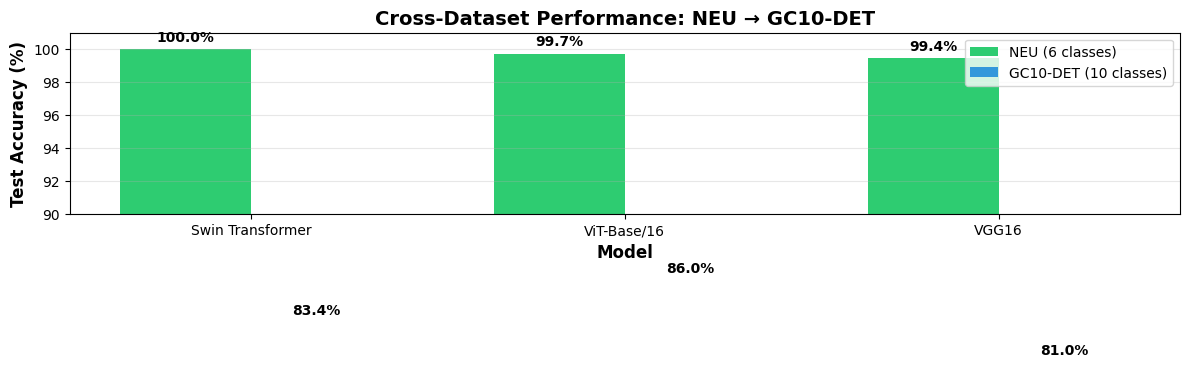

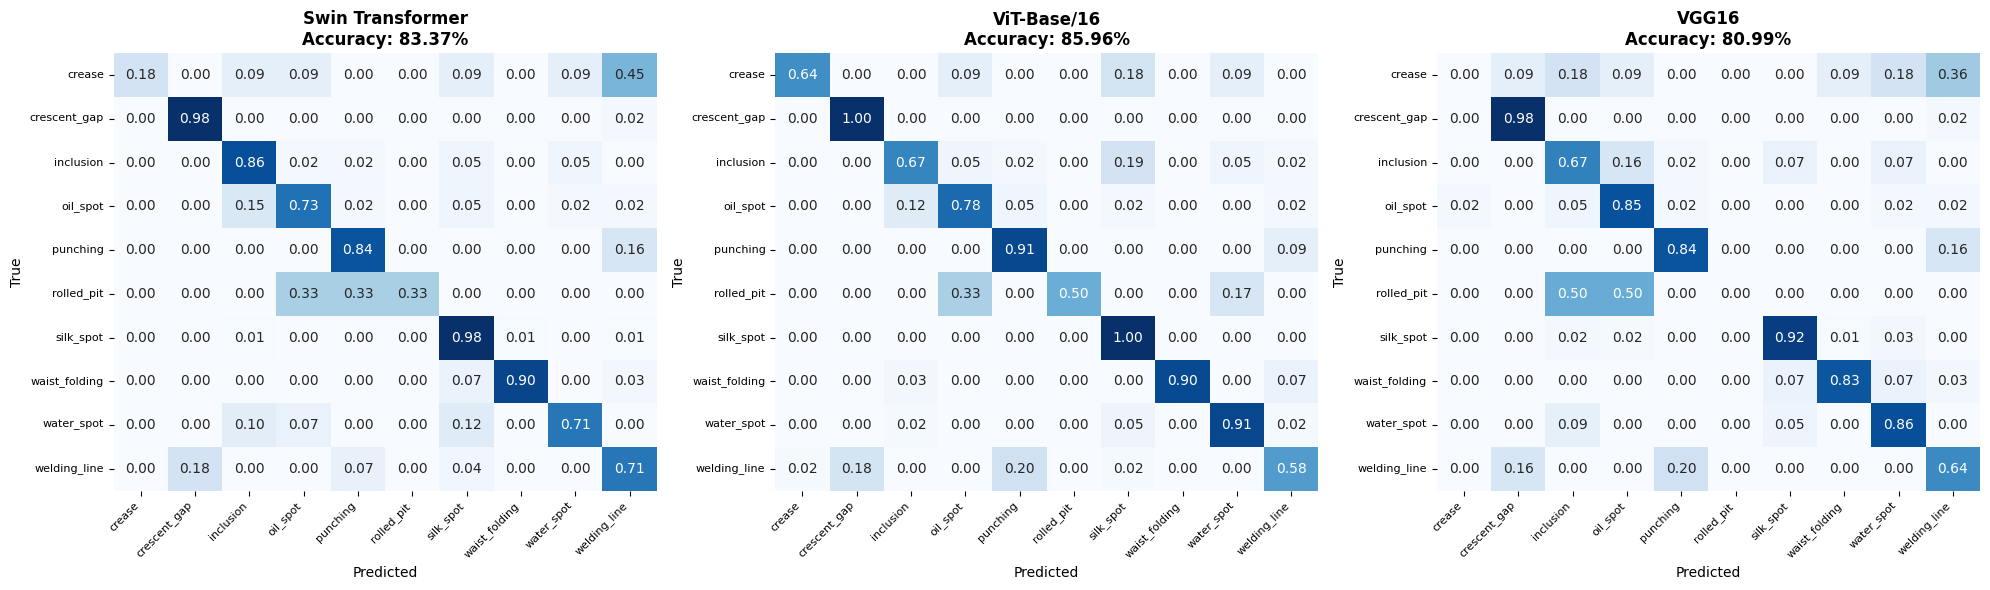

✓ All visualizations saved

🎉 ALL TRAINING COMPLETE! 🎉

CROSS-DATASET GENERALIZATION RESULTS:

1. ViT-Base/16         
   NEU (6 classes):     99.72%
   GC10-DET (10 classes): 85.96%
   Accuracy drop:       13.76%
   Training time:       30.9 min

2. Swin Transformer    
   NEU (6 classes):     100.00%
   GC10-DET (10 classes): 83.37%
   Accuracy drop:       16.63%
   Training time:       23.3 min

3. VGG16               
   NEU (6 classes):     99.44%
   GC10-DET (10 classes): 80.99%
   Accuracy drop:       18.45%
   Training time:       26.0 min

FILES SAVED:
  ✓ Models: /content/drive/MyDrive/FINAL PROJECT/Results/models/
     - swin_transformer_gc10_best.pth
     - vit_base_16_gc10_best.pth
     - vgg16_gc10_best.pth

  ✓ Figures: /content/drive/MyDrive/FINAL PROJECT/Results/figures/
     - gc10_all_models_comparison.png
     - gc10_all_confusion_matrices.png

  ✓ Results: /content/drive/MyDrive/FINAL PROJECT/Results/
     - gc10_crossdataset_comparison.csv

Completed at: 2026-03-2

In [3]:
"""
================================================================================
GC10-DET CROSS-DATASET VALIDATION - TOP 3 MODELS SEQUENTIAL TRAINING
Automatically trains: Swin Transformer, ViT-Base/16, VGG16
================================================================================
"""

# ============================================================================
# SECTION 1: IMPORTS & SETUP
# ============================================================================

import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("="*80)
print("GC10-DET CROSS-DATASET VALIDATION")
print("SEQUENTIAL TRAINING: SWIN → ViT → VGG16")
print("="*80)
print()
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print()

# Mount drive
from google.colab import drive
drive.mount('/content/drive')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("✓ Setup complete")


# ============================================================================
# SECTION 2: PATHS & DATA LOADING
# ============================================================================

print("\n" + "="*80)
print("LOADING GC10-DET DATASET")
print("="*80)

GC10_ORGANIZED = Path('/content/drive/MyDrive/FINAL PROJECT/GC10-DET/organized')
RESULTS_DIR = Path('/content/drive/MyDrive/FINAL PROJECT/Results')
RESULTS_DIR.mkdir(exist_ok=True)
(RESULTS_DIR / 'figures').mkdir(exist_ok=True)

# Get classes
classes = sorted([d.name for d in GC10_ORGANIZED.iterdir() if d.is_dir()])
print(f"\nFound {len(classes)} classes:")
for idx, cls in enumerate(classes):
    count = len(list((GC10_ORGANIZED / cls).glob('*.jpg')))
    print(f"  {idx}: {cls:20s} - {count:3d} images")

# Load all images
data_list = []
for class_idx, class_name in enumerate(classes):
    for img_path in (GC10_ORGANIZED / class_name).glob('*.jpg'):
        data_list.append({
            'image_path': str(img_path),
            'class_name': class_name,
            'class_id': class_idx
        })

df = pd.DataFrame(data_list)
print(f"\nTotal: {len(df)} images")

# Split 80/20
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['class_id'])
print(f"Train: {len(train_df)}, Test: {len(test_df)}")


# ============================================================================
# SECTION 3: DATASET & TRANSFORMS
# ============================================================================

class GC10Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, row['class_id']

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

BATCH_SIZE = 32
train_dataset = GC10Dataset(train_df, transform=train_transform)
test_dataset = GC10Dataset(test_df, transform=test_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("✓ Dataset ready")


# ============================================================================
# SECTION 4: TRAINING FUNCTIONS
# ============================================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.2f}%'})

    return running_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / len(loader), 100. * correct / total, np.array(all_preds), np.array(all_labels)


def train_model(model_name, model, num_epochs=20):
    """Train a single model and return results."""
    print("\n" + "="*80)
    print(f"TRAINING: {model_name}")
    print("="*80)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    best_test_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    start_time = time.time()

    for epoch in range(num_epochs):
        print(f"\nEpoch [{epoch+1}/{num_epochs}]")

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)

        scheduler.step(test_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.2f}%")

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            save_name = model_name.lower().replace('/', '_').replace('-', '_')
            torch.save({
                'model_state_dict': model.state_dict(),
                'test_acc': test_acc,
                'epoch': epoch
            }, RESULTS_DIR / f'models/{save_name}_gc10_best.pth')
            print(f"  ✓ Best model saved ({test_acc:.2f}%)")

    training_time = time.time() - start_time

    # Load best model and get final predictions
    save_name = model_name.lower().replace('/', '_').replace('-', '_')
    checkpoint = torch.load(RESULTS_DIR / f'models/{save_name}_gc10_best.pth')
    model.load_state_dict(checkpoint['model_state_dict'])

    test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
    cm = confusion_matrix(test_labels, test_preds)

    print("\n" + "="*80)
    print(f"{model_name} COMPLETE!")
    print("="*80)
    print(f"Time: {training_time/60:.1f} minutes")
    print(f"Best Test Accuracy: {best_test_acc:.2f}%")
    print(f"Final Test Accuracy: {test_acc:.2f}%")

    return {
        'model_name': model_name,
        'test_acc': test_acc,
        'best_test_acc': best_test_acc,
        'training_time': training_time,
        'history': history,
        'confusion_matrix': cm,
        'predictions': test_preds,
        'labels': test_labels
    }

print("✓ Training functions defined")


# ============================================================================
# SECTION 5: MODEL DEFINITIONS
# ============================================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def create_swin_transformer():
    """Load Swin Transformer pre-trained on NEU."""
    model = models.swin_t(pretrained=False)
    checkpoint = torch.load(RESULTS_DIR / 'models/swin_t_best.pth', map_location=device)
    model_state = {k: v for k, v in checkpoint['model_state_dict'].items() if not k.startswith('head')}
    model.load_state_dict(model_state, strict=False)
    model.head = nn.Linear(model.head.in_features, len(classes))

    for param in model.parameters():
        param.requires_grad = False
    for param in model.head.parameters():
        param.requires_grad = True

    return model


def create_vit():
    """Load ViT-Base/16 pre-trained on NEU."""
    model = models.vit_b_16(pretrained=False)
    checkpoint = torch.load(RESULTS_DIR / 'models/vit_base_16_best.pth', map_location=device)
    model_state = {k: v for k, v in checkpoint['model_state_dict'].items() if not k.startswith('heads')}
    model.load_state_dict(model_state, strict=False)
    model.heads.head = nn.Linear(model.heads.head.in_features, len(classes))

    for param in model.parameters():
        param.requires_grad = False
    for param in model.heads.head.parameters():
        param.requires_grad = True

    return model


def create_vgg16():
    """Load VGG16 pre-trained on NEU."""
    model = models.vgg16(pretrained=False)
    checkpoint = torch.load(RESULTS_DIR / 'models/vgg16_best.pth', map_location=device)
    model_state = {k: v for k, v in checkpoint['model_state_dict'].items() if not k.startswith('classifier')}
    model.load_state_dict(model_state, strict=False)

    num_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(num_features, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(4096, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(4096, len(classes))
    )

    for name, param in model.named_parameters():
        if not name.startswith('classifier'):
            param.requires_grad = False

    return model

print("✓ Model creators defined")


# ============================================================================
# SECTION 6: TRAIN ALL MODELS SEQUENTIALLY
# ============================================================================

print("\n" + "="*80)
print("STARTING SEQUENTIAL TRAINING OF 3 MODELS")
print("="*80)
print("\nModels to train:")
print("  1. Swin Transformer (NEU: 100.00%)")
print("  2. ViT-Base/16      (NEU: 99.72%)")
print("  3. VGG16            (NEU: 99.44%)")
print()
print("Estimated total time: 5-6 hours")
print("You can leave this running and come back later!")
print("="*80)

all_results = []

# Model 1: Swin Transformer
print("\n" + "🔥"*40)
print("MODEL 1/3: SWIN TRANSFORMER")
print("🔥"*40)
model_swin = create_swin_transformer()
result_swin = train_model("Swin Transformer", model_swin, num_epochs=20)
all_results.append(result_swin)
del model_swin
torch.cuda.empty_cache()

# Model 2: ViT-Base/16
print("\n" + "🔥"*40)
print("MODEL 2/3: ViT-Base/16")
print("🔥"*40)
model_vit = create_vit()
result_vit = train_model("ViT-Base/16", model_vit, num_epochs=20)
all_results.append(result_vit)
del model_vit
torch.cuda.empty_cache()

# Model 3: VGG16
print("\n" + "🔥"*40)
print("MODEL 3/3: VGG16")
print("🔥"*40)
model_vgg = create_vgg16()
result_vgg = train_model("VGG16", model_vgg, num_epochs=20)
all_results.append(result_vgg)
del model_vgg
torch.cuda.empty_cache()


# ============================================================================
# SECTION 7: RESULTS COMPARISON
# ============================================================================

print("\n" + "="*80)
print("ALL MODELS TRAINED! COMPARING RESULTS...")
print("="*80)

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': [r['model_name'] for r in all_results],
    'NEU Accuracy (%)': [100.00, 99.72, 99.44],
    'GC10-DET Accuracy (%)': [r['test_acc'] for r in all_results],
    'Training Time (min)': [r['training_time']/60 for r in all_results]
})

comparison_df['Accuracy Drop (%)'] = comparison_df['NEU Accuracy (%)'] - comparison_df['GC10-DET Accuracy (%)']
comparison_df = comparison_df.sort_values('GC10-DET Accuracy (%)', ascending=False)

print("\n" + "="*80)
print("CROSS-DATASET PERFORMANCE COMPARISON")
print("="*80)
print()
print(comparison_df.to_string(index=False))
print()

# Save to CSV
comparison_df.to_csv(RESULTS_DIR / 'gc10_crossdataset_comparison.csv', index=False)
print("✓ Comparison saved to gc10_crossdataset_comparison.csv")


# ============================================================================
# SECTION 8: VISUALIZATIONS
# ============================================================================

print("\nCreating visualizations...")

# 1. Accuracy comparison bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(all_results))
width = 0.35

neu_accs = [100.00, 99.72, 99.44]
gc10_accs = [r['test_acc'] for r in all_results]

ax.bar(x - width/2, neu_accs, width, label='NEU (6 classes)', color='#2ecc71')
ax.bar(x + width/2, gc10_accs, width, label='GC10-DET (10 classes)', color='#3498db')

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Cross-Dataset Performance: NEU → GC10-DET', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([r['model_name'] for r in all_results])
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(90, 101)

for i, (neu, gc10) in enumerate(zip(neu_accs, gc10_accs)):
    ax.text(i - width/2, neu + 0.3, f'{neu:.1f}%', ha='center', va='bottom', fontweight='bold')
    ax.text(i + width/2, gc10 + 0.3, f'{gc10:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures/gc10_all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Confusion matrices (3 subplots)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, result in enumerate(all_results):
    cm = result['confusion_matrix']
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[idx],
                xticklabels=classes, yticklabels=classes, cbar=False)
    axes[idx].set_title(f"{result['model_name']}\nAccuracy: {result['test_acc']:.2f}%",
                       fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('True', fontsize=10)
    axes[idx].tick_params(labelsize=8)
    plt.setp(axes[idx].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures/gc10_all_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ All visualizations saved")


# ============================================================================
# SECTION 9: FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("🎉 ALL TRAINING COMPLETE! 🎉")
print("="*80)
print()
print("CROSS-DATASET GENERALIZATION RESULTS:")
print()

for idx, result in enumerate(sorted(all_results, key=lambda x: x['test_acc'], reverse=True), 1):
    neu_acc = [100.00, 99.72, 99.44][[r['model_name'] for r in all_results].index(result['model_name'])]
    drop = neu_acc - result['test_acc']

    print(f"{idx}. {result['model_name']:20s}")
    print(f"   NEU (6 classes):     {neu_acc:.2f}%")
    print(f"   GC10-DET (10 classes): {result['test_acc']:.2f}%")
    print(f"   Accuracy drop:       {drop:.2f}%")
    print(f"   Training time:       {result['training_time']/60:.1f} min")
    print()

print("="*80)
print("FILES SAVED:")
print("="*80)
print(f"  ✓ Models: {RESULTS_DIR}/models/")
print(f"     - swin_transformer_gc10_best.pth")
print(f"     - vit_base_16_gc10_best.pth")
print(f"     - vgg16_gc10_best.pth")
print()
print(f"  ✓ Figures: {RESULTS_DIR}/figures/")
print(f"     - gc10_all_models_comparison.png")
print(f"     - gc10_all_confusion_matrices.png")
print()
print(f"  ✓ Results: {RESULTS_DIR}/")
print(f"     - gc10_crossdataset_comparison.csv")
print()
print("="*80)
print(f"Completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)
print()
print("🎊 READY FOR PRESENTATION! 🎊")